--- ANTRENARE ISOLATION FOREST PE DATELE eBPF [ACCELERAT GPU] ---
Dispozitiv detectat: cuda
Date partajate: Train_Normal=25980, Test_Total=13559
Antrenare structurală arbori pe CPU...
Antrenare finalizată în 0.53 secunde!
Execuție inferență paralelă pe nucleele CUDA...
Inferență pe GPU finalizată în 0.6688s

RAPORT METRICI:
REZULTATE EBPF ISOLATION FOREST GPU (ALINIAT CPU)
AUC: 0.9575
Timp Antrenare: 0.53s

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     11161
        Atac       0.77      0.79      0.78      2398

    accuracy                           0.92     13559
   macro avg       0.86      0.87      0.87     13559
weighted avg       0.92      0.92      0.92     13559



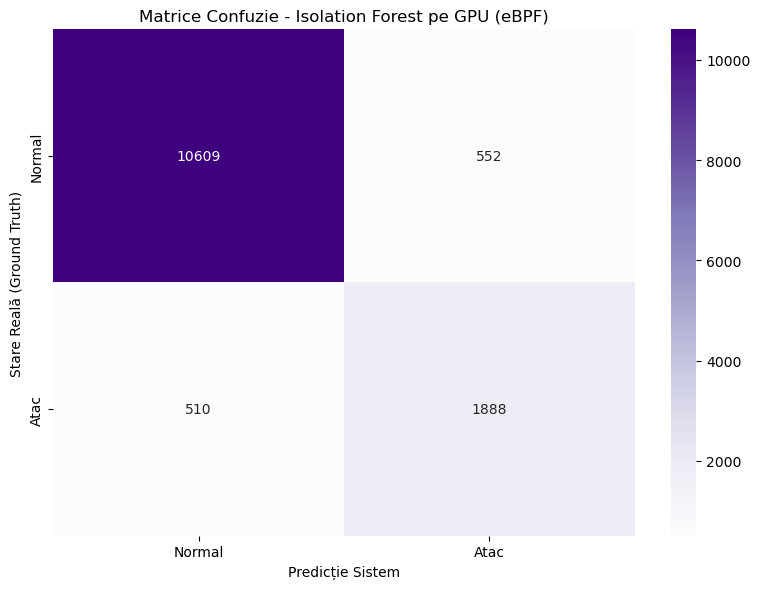

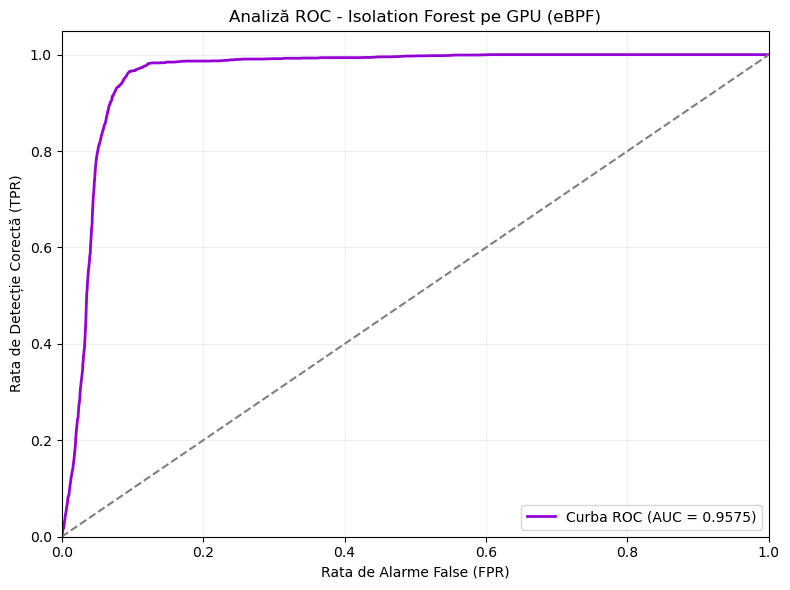


Toate rezultatele și graficele au fost salvate în: D:\disertatie\eBPF_WSL\rezultate_eBPF\Isolation_Forest


In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\Isolation_Forest'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ISOLATION FOREST PE DATELE eBPF [ACCELERAT GPU] ---")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispozitiv detectat: {device}")

df = pd.read_csv(dataset_path)
X_raw = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

rng = np.random.default_rng(42)
X_clean = X_scaled + rng.normal(0, 1e-5, size=X_scaled.shape)

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_clean[train_indices][y[train_indices] == 0]
X_test = X_clean[test_indices]
y_test = y[test_indices]

X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)

print(f"Date partajate: Train_Normal={len(X_train)}, Test_Total={len(X_test)}")

iso_forest = IsolationForest(n_estimators=200, contamination=0.15, random_state=42, n_jobs=-1)

start_time = time.time()
print("Antrenare structurală arbori pe CPU...")
iso_forest.fit(X_train)
train_time = time.time() - start_time
print(f"Antrenare finalizată în {train_time:.2f} secunde!")

def predict_iforest_pytorch(iforest_model, X_tensor):
    n_samples = X_tensor.shape[0]
    n_estimators = len(iforest_model.estimators_)
    paths_length = torch.zeros((n_samples, n_estimators), device=device)
    
    for i, estimator in enumerate(iforest_model.estimators_):
        tree = estimator.tree_
        left_children = torch.tensor(tree.children_left, dtype=torch.long, device=device)
        right_children = torch.tensor(tree.children_right, dtype=torch.long, device=device)
        features = torch.tensor(tree.feature, dtype=torch.long, device=device)
        thresholds = torch.tensor(tree.threshold, dtype=torch.float32, device=device)
        
        node_indicator = torch.zeros(n_samples, dtype=torch.long, device=device)
        depths = torch.zeros(n_samples, device=device)
        
        while True:
            current_features = features[node_indicator]
            is_leaf = current_features == -2
            if torch.all(is_leaf):
                break
                
            going_left = X_tensor[torch.arange(n_samples), current_features] <= thresholds[node_indicator]
            
            node_indicator = torch.where(
                is_leaf, 
                node_indicator, 
                torch.where(going_left, left_children[node_indicator], right_children[node_indicator])
            )
            depths = torch.where(is_leaf, depths, depths + 1)
            
        paths_length[:, i] = depths
        
    mean_paths = torch.mean(paths_length, dim=1)
    
    def c_factor(n):
        if n <= 1:
            return 0.0
        if n == 2:
            return 1.0
        return 2.0 * (np.log(n - 1) + 0.5772156649) - (2.0 * (n - 1) / n)
        
    c = c_factor(iforest_model.max_samples_)
    scores = -torch.pow(2.0, - (mean_paths / (c + 1e-10)))
    return scores

print("Execuție inferență paralelă pe nucleele CUDA...")
start_inference = time.time()
with torch.no_grad():
    decision_scores_tensor = predict_iforest_pytorch(iso_forest, X_test_tensor)
    decision_scores = decision_scores_tensor.cpu().numpy()
print(f"Inferență pe GPU finalizată în {time.time() - start_inference:.4f}s")

percentila_dorita = 18
prag_dinamic = np.percentile(decision_scores, percentila_dorita)
y_pred = np.where(decision_scores < prag_dinamic, 1, 0)

y_scores = -decision_scores
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])
full_report = f"REZULTATE EBPF ISOLATION FOREST GPU (ALINIAT CPU)\nAUC: {roc_auc:.4f}\nTimp Antrenare: {train_time:.2f}s\n\n{report}"
print("\nRAPORT METRICI:")
print(full_report)

with open(os.path.join(rezultate_path, 'raport_ebpf_iso_forest_gpu.txt'), 'w') as f:
    f.write(full_report)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - Isolation Forest pe GPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - Isolation Forest pe GPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_gpu.png'), dpi=300)
plt.show()

with open(os.path.join(rezultate_path, 'model_ebpf_iso_forest_gpu.pkl'), 'wb') as f:
    pickle.dump(iso_forest, f)

print(f"\nToate rezultatele și graficele au fost salvate în: {rezultate_path}")